# Tutorial 13: JUMP Cell Painting Morphological Embeddings

This notebook demonstrates how to load and analyse **JUMP Cell Painting**
morphological embeddings. The [JUMP](https://jump-cellpainting.broadinstitute.org/)
(Joint Undertaking for Morphological Profiling) consortium performed
large-scale CRISPR perturbation screens in U2OS cells, measuring over
3,000 image-derived cellular morphology features via Cell Painting.

We use the **batch-corrected CRISPR embeddings** from the
[Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/):

- **51,185 wells** across 148 plates
- **7,977 unique gene perturbations** (identified by JCP2022 IDs)
- **259-dimensional** PCA-reduced embeddings after Harmony batch correction

### What you'll learn

1. Load JUMP CRISPR embeddings from parquet
2. Map JCP2022 identifiers to gene names with `broad-babel`
3. Separate treatments from negative controls
4. Compute per-gene mean embeddings (pseudobulk)
5. Find morphologically similar gene perturbations
6. Visualise the morphological landscape with PCA
7. Store embeddings as AnnData for downstream analysis

### Requirements

```bash
pip install broad-babel pyarrow
```

Download the embeddings first:
```bash
mkdir -p data/JUMP
wget -O data/JUMP/profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony_PCA_corrected.parquet \
  "https://cellpainting-gallery.s3.amazonaws.com/cpg0016-jump-assembled/source_all/workspace/profiles_assembled/CRISPR/v1.0a/profiles_wellpos_cc_var_mad_outlier_featselect_sphering_harmony_PCA_corrected.parquet"
```

In [10]:
import logging

logging.basicConfig(level=logging.INFO)

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Load the JUMP CRISPR embeddings

The parquet file contains well-level embeddings (259 PCA components)
with metadata columns for source, plate, well, and JCP2022 perturbation ID.

In [12]:
JUMP_DIR = Path("/lustre/groups/ml01/workspace/goncalo.pinto/embpy/data/datasets/JUMP")
PARQUET_FILE = JUMP_DIR / "crispr" / "standard.parquet"

df = pd.read_parquet(PARQUET_FILE)
print(f"Shape: {df.shape}")
df.head()

Shape: (51185, 263)


,Metadata_Source,Metadata_Plate,Metadata_Well,Metadata_JCP2022,X_1,X_2,X_3,X_4,X_5,X_6,...,X_250,X_251,X_252,X_253,X_254,X_255,X_256,X_257,X_258,X_259
0,source_13,CP-CC9-R1-01,A02,JCP2022_800002,-0.223417,-0.049487,-0.826231,0.345093,-0.273055,-0.186349,...,-0.041767,0.073491,-0.157532,-0.071469,-0.037753,0.053746,0.023982,0.156385,-0.064430,0.004538
1,source_13,CP-CC9-R1-01,K14,JCP2022_804257,-0.066288,0.076715,-1.067553,-0.367578,0.122728,-0.823368,...,0.034426,0.033929,0.102059,0.144348,0.208035,0.050269,0.001003,0.027160,-0.040426,-0.049395
2,source_13,CP-CC9-R1-01,L23,JCP2022_800002,-0.079349,-0.016958,-0.277558,-0.625543,-0.236846,-0.140912,...,0.025519,0.134598,-0.018768,-0.079568,-0.214031,0.031374,-0.079467,0.001434,0.063802,-0.003757
3,source_13,CP-CC9-R1-01,K02,JCP2022_800001,-0.271417,-0.117471,0.462461,-0.480330,-0.406793,-0.691130,...,-0.129316,0.224771,0.204519,-0.081960,0.038231,0.081065,-0.009409,0.077791,-0.043725,0.086840
4,source_13,CP-CC9-R1-01,I08,JCP2022_800001,0.008612,-0.059106,-1.081568,-1.246591,0.025878,-0.241614,...,0.005117,-0.077804,0.038525,0.089097,0.074524,-0.120086,-0.038295,0.024144,0.140383,-0.023736


In [13]:
meta_cols = [c for c in df.columns if c.startswith("Metadata_")]
feat_cols = [c for c in df.columns if not c.startswith("Metadata_")]

print(f"Metadata columns ({len(meta_cols)}): {meta_cols}")
print(f"Embedding dimensions: {len(feat_cols)}")
print(f"Unique perturbations: {df['Metadata_JCP2022'].nunique():,}")
print(f"Unique plates: {df['Metadata_Plate'].nunique()}")

Metadata columns (4): ['Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_JCP2022']
Embedding dimensions: 259
Unique perturbations: 7,977
Unique plates: 148


## 2. Map JCP2022 IDs to gene names

The perturbations are identified by JCP2022 codes. We use
[broad-babel](https://pypi.org/project/broad-babel/) to translate
them to standard gene symbols.

In [14]:
from broad_babel.query import get_mapper

mapper = get_mapper(
    query="crispr",
    input_column="plate_type",
    output_columns="JCP2022,standard_key",
)
print(f"Mapper contains {len(mapper):,} JCP2022 -> gene mappings")
print("Sample:", dict(list(mapper.items())[:5]))

Mapper contains 7,977 JCP2022 -> gene mappings
Sample: {'JCP2022_801630': 'CYP27B1', 'JCP2022_804298': 'MST1R', 'JCP2022_804469': 'NDST2', 'JCP2022_800100': 'ACAT1', 'JCP2022_803013': 'HAL'}


In [15]:
df["gene"] = df["Metadata_JCP2022"].map(mapper)

mapped = df["gene"].notna().sum()
total = len(df)
print(f"Mapped {mapped:,} / {total:,} wells ({100*mapped/total:.1f}%)")
print(f"Unmapped JCP IDs: {df.loc[df['gene'].isna(), 'Metadata_JCP2022'].unique()[:10]}")

Mapped 51,185 / 51,185 wells (100.0%)
Unmapped JCP IDs: <StringArray>
[]
Length: 0, dtype: string


## 3. Separate treatments from negative controls

JCP2022_800001 and JCP2022_800002 are non-targeting negative controls.

In [16]:
NEGCON_IDS = {"JCP2022_800001", "JCP2022_800002"}

df["is_control"] = df["Metadata_JCP2022"].isin(NEGCON_IDS)

n_ctrl = df["is_control"].sum()
n_trt = (~df["is_control"]).sum()
print(f"Negative controls: {n_ctrl:,} wells")
print(f"Treatments: {n_trt:,} wells")
print(f"Unique treated genes: {df.loc[~df['is_control'], 'Metadata_JCP2022'].nunique():,}")

Negative controls: 7,478 wells
Treatments: 43,707 wells
Unique treated genes: 7,975


## 4. Embedding distribution

Compare the distribution of embedding magnitudes between
controls and treatments.

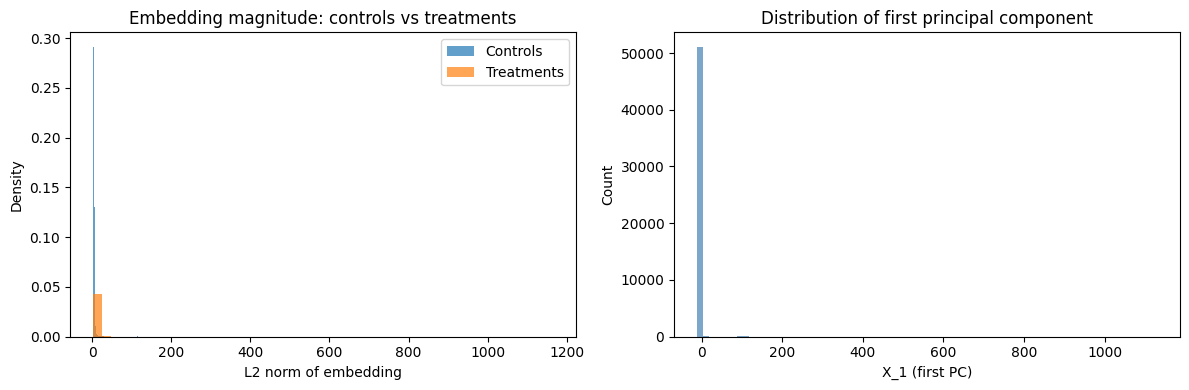

In [17]:
X = df[feat_cols].values.astype(np.float32)

norms = np.linalg.norm(X, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(norms[df["is_control"].values], bins=50, alpha=0.7, label="Controls", density=True)
axes[0].hist(norms[~df["is_control"].values], bins=50, alpha=0.7, label="Treatments", density=True)
axes[0].set_xlabel("L2 norm of embedding")
axes[0].set_ylabel("Density")
axes[0].set_title("Embedding magnitude: controls vs treatments")
axes[0].legend()

axes[1].hist(X[:, 0], bins=80, alpha=0.7, color="steelblue")
axes[1].set_xlabel("X_1 (first PC)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of first principal component")

plt.tight_layout()
plt.show()

## 5. Per-gene mean embeddings (pseudobulk)

Aggregate replicate wells per perturbation to get a single
embedding per gene.

In [18]:
trt = df[~df["is_control"]].copy()

gene_embs = trt.groupby("Metadata_JCP2022")[feat_cols].mean()
gene_embs["gene"] = gene_embs.index.map(mapper)

print(f"Per-gene embeddings: {gene_embs.shape[0]:,} genes x {len(feat_cols)} dims")
gene_embs.head()

Per-gene embeddings: 7,975 genes x 259 dims


,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,...,X_251,X_252,X_253,X_254,X_255,X_256,X_257,X_258,X_259,gene
Metadata_JCP2022,,,,,,,,,,,,,,,,,,,,,
JCP2022_800003,-0.086932,-0.009669,-0.133489,0.129359,-0.208854,0.217102,-0.310685,-0.145211,0.287919,0.288320,...,-0.048816,-0.034460,-0.030420,-0.021265,0.095967,0.016251,-0.032128,-0.006704,-0.148176,A2M
JCP2022_800004,-0.060077,-0.033927,-0.327083,0.012593,0.375724,-0.397318,0.175571,-0.115255,0.369196,-0.036875,...,-0.014055,-0.001140,-0.119431,0.043546,-0.020634,0.082892,0.095720,0.086828,-0.059658,A3GALT2
JCP2022_800005,-0.740078,-0.136058,-0.395633,0.998648,-0.408881,0.659256,-0.258719,-0.442769,-0.227844,-0.520845,...,0.019006,-0.018146,0.129822,0.064767,-0.035434,0.108807,-0.036622,0.040975,-0.023401,A4GALT
JCP2022_800006,-0.041815,-0.006730,-0.487745,-0.163427,-0.315825,0.044891,-0.307501,0.387960,-0.072157,-0.135160,...,0.043984,0.001210,-0.051557,0.021240,0.001292,0.001675,-0.067669,-0.024120,-0.004079,A4GNT
JCP2022_800007,-0.074485,-0.070641,-0.570315,1.005951,-0.219352,-0.478007,-1.179395,-0.765865,0.271563,-0.238804,...,0.079823,-0.006835,0.041213,-0.022556,0.051077,-0.006424,-0.051485,0.049977,0.126653,AACS


## 6. Find morphologically similar perturbations

Given a gene of interest, find the perturbations with the
most similar morphological profile using cosine similarity.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

X_genes = gene_embs[feat_cols].values.astype(np.float32)
gene_labels = gene_embs["gene"].values
jcp_ids = gene_embs.index.values

sim_matrix = cosine_similarity(X_genes)
print(f"Similarity matrix: {sim_matrix.shape}")

Similarity matrix: (7975, 7975)


In [20]:
def find_similar_genes(query_gene, gene_labels, sim_matrix, top_k=10):
    """Find the top-k most similar gene perturbations."""
    matches = np.where(gene_labels == query_gene)[0]
    if len(matches) == 0:
        jcp_match = np.where(jcp_ids == query_gene)[0]
        if len(jcp_match) == 0:
            print(f"Gene '{query_gene}' not found.")
            return None
        idx = jcp_match[0]
    else:
        idx = matches[0]

    sims = sim_matrix[idx]
    top_idx = np.argsort(sims)[::-1][1 : top_k + 1]

    results = pd.DataFrame({
        "gene": gene_labels[top_idx],
        "jcp_id": jcp_ids[top_idx],
        "cosine_sim": sims[top_idx],
    })
    return results


query = "TP53"
similar = find_similar_genes(query, gene_labels, sim_matrix, top_k=15)
if similar is not None:
    print(f"\nTop 15 genes most similar to {query} (morphological profile):")
    print(similar.to_string(index=False))


Top 15 genes most similar to TP53 (morphological profile):
    gene         jcp_id  cosine_sim
    ENO1 JCP2022_802110    0.623335
    EAF1 JCP2022_801977    0.621339
  TOPBP1 JCP2022_807200    0.590129
   DMTF1 JCP2022_801853    0.589909
CDC42BPG JCP2022_801182    0.555621
   RAD51 JCP2022_805807    0.547807
   MARK2 JCP2022_804035    0.543310
   ARIH1 JCP2022_800583    0.533863
PPP1R12A JCP2022_805440    0.528633
   TOP2A JCP2022_807196    0.525837
 TSC22D1 JCP2022_807358    0.520057
  PPP1CB JCP2022_805437    0.519202
  GPR176 JCP2022_802835    0.512171
 PRKAR1B JCP2022_805524    0.510890
   MKNK2 JCP2022_804188    0.506984


## 7. PCA visualisation of the morphological landscape

Project the per-gene embeddings to 2D for visualisation.
We highlight a few genes of interest.

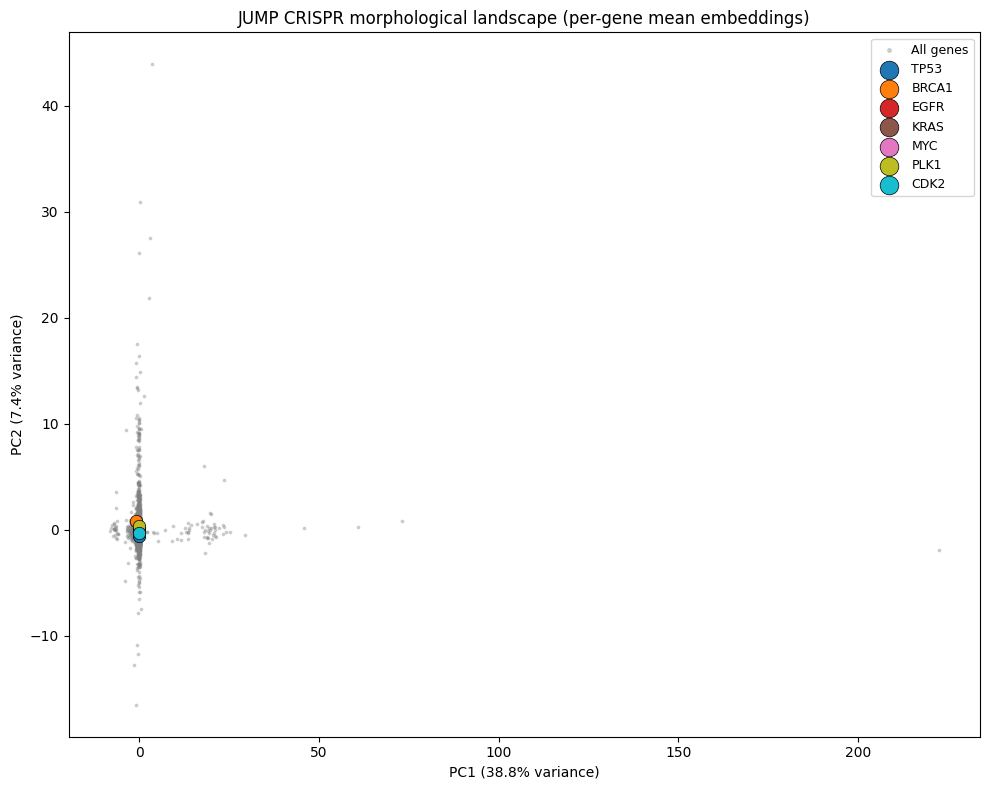

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_genes)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords[:, 0], coords[:, 1], s=3, alpha=0.3, c="grey", label="All genes")

highlight_genes = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC", "PLK1", "CDK2"]
colors = plt.cm.tab10(np.linspace(0, 1, len(highlight_genes)))

for gene, color in zip(highlight_genes, colors):
    mask = gene_labels == gene
    if mask.any():
        ax.scatter(coords[mask, 0], coords[mask, 1], s=80, c=[color],
                   edgecolors="black", linewidths=0.5, label=gene, zorder=5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("JUMP CRISPR morphological landscape (per-gene mean embeddings)")
ax.legend(markerscale=1.5, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Cosine similarity heatmap for selected genes

Visualise pairwise morphological similarity for a set of
cancer-relevant genes.

Found 16 / 16 genes


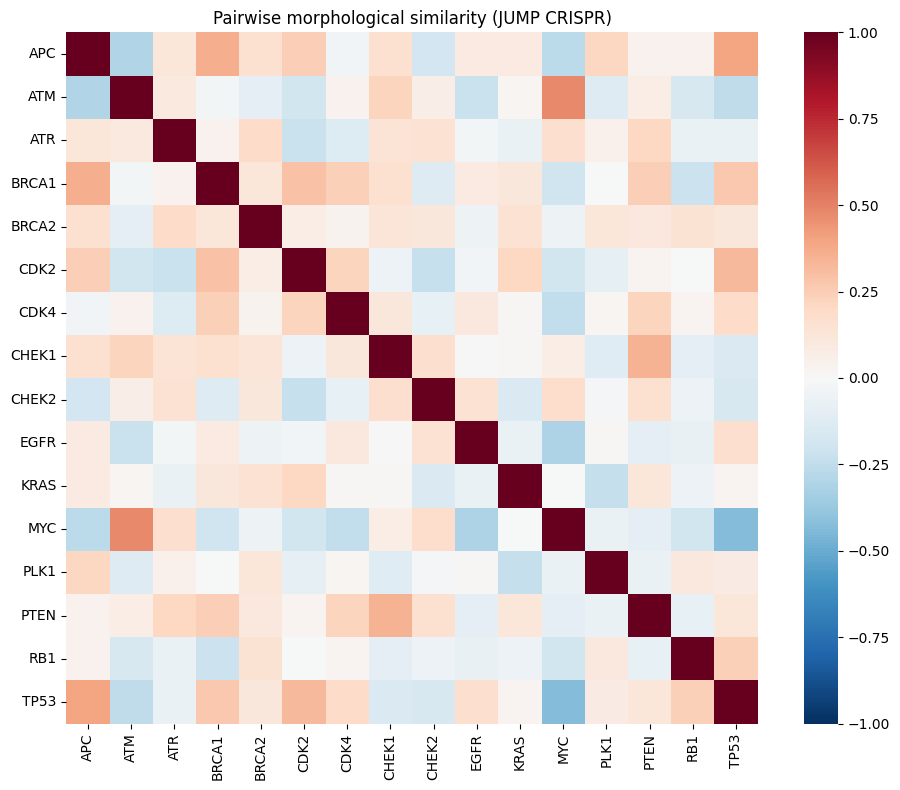

In [22]:
genes_of_interest = [
    "TP53", "BRCA1", "BRCA2", "EGFR", "KRAS", "MYC",
    "PLK1", "CDK2", "CDK4", "RB1", "PTEN", "APC",
    "ATM", "ATR", "CHEK1", "CHEK2",
]

mask = np.isin(gene_labels, genes_of_interest)
found_genes = gene_labels[mask]
print(f"Found {mask.sum()} / {len(genes_of_interest)} genes")

sub_X = X_genes[mask]
sub_sim = cosine_similarity(sub_X)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sub_sim,
    xticklabels=found_genes,
    yticklabels=found_genes,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)
ax.set_title("Pairwise morphological similarity (JUMP CRISPR)")
plt.tight_layout()
plt.show()

## 9. Store as AnnData

Convert the per-gene embeddings into an AnnData object for
integration with other `embpy` workflows.

In [23]:
import anndata as ad

gene_embs_clean = gene_embs.dropna(subset=["gene"])

adata = ad.AnnData(
    X=gene_embs_clean[feat_cols].values.astype(np.float32),
    obs=pd.DataFrame({
        "jcp_id": gene_embs_clean.index,
        "gene": gene_embs_clean["gene"].values,
    }).set_index("gene"),
)
adata.var_names = [f"JUMP_PC{i+1}" for i in range(len(feat_cols))]

print(adata)
print(f"\nFirst 5 genes: {adata.obs_names[:5].tolist()}")

AnnData object with n_obs × n_vars = 7975 × 259
    obs: 'jcp_id'

First 5 genes: ['A2M', 'A3GALT2', 'A4GALT', 'A4GNT', 'AACS']


In [24]:
adata.obsm["X_pca"] = PCA(n_components=50).fit_transform(adata.X)
print(f"Stored PCA(50) in adata.obsm['X_pca']: {adata.obsm['X_pca'].shape}")
adata

Stored PCA(50) in adata.obsm['X_pca']: (7975, 50)


AnnData object with n_obs × n_vars = 7975 × 259
    obs: 'jcp_id'
    obsm: 'X_pca'

## 10. Replicate reproducibility

Assess how reproducible the morphological signal is across
replicate wells for the same perturbation.

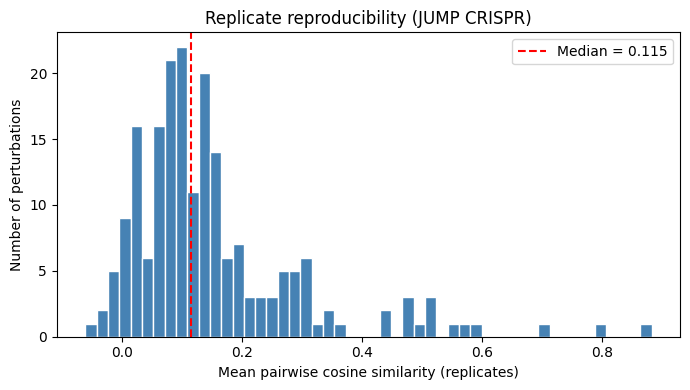

In [25]:
n_sample = 200
rng = np.random.default_rng(42)
sampled_jcps = rng.choice(
    trt["Metadata_JCP2022"].unique(), size=min(n_sample, trt["Metadata_JCP2022"].nunique()), replace=False
)

rep_corrs = []
for jcp in sampled_jcps:
    wells = trt.loc[trt["Metadata_JCP2022"] == jcp, feat_cols].values
    if len(wells) >= 2:
        sims = cosine_similarity(wells)
        upper = sims[np.triu_indices_from(sims, k=1)]
        rep_corrs.append(upper.mean())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rep_corrs, bins=50, edgecolor="white", color="steelblue")
ax.axvline(np.median(rep_corrs), color="red", linestyle="--", label=f"Median = {np.median(rep_corrs):.3f}")
ax.set_xlabel("Mean pairwise cosine similarity (replicates)")
ax.set_ylabel("Number of perturbations")
ax.set_title("Replicate reproducibility (JUMP CRISPR)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. SubCell morphology embeddings

[SubCell](https://github.com/CellProfiling/SubCellPortable) is a suite
of ViT-MAE vision foundation models trained on Human Protein Atlas
fluorescence images. It takes multi-channel fluorescence images and
produces rich cell morphology embeddings.

**8 model variants** across 4 channel configs x 2 architectures:

| Variant | Channels | Architecture |
|---------|----------|-------------|
| `subcell_mae_rybg` | 4ch (Red, Yellow, Blue, Green) | MAE + contrastive |
| `subcell_vit_rybg` | 4ch | ViT + supervised contrastive |
| `subcell_mae_rbg` | 3ch (Red, Blue, Green) | MAE + contrastive |
| `subcell_vit_rbg` | 3ch | ViT + supervised contrastive |
| `subcell_mae_ybg` | 3ch (Yellow, Blue, Green) | MAE + contrastive |
| `subcell_vit_ybg` | 3ch | ViT + supervised contrastive |
| `subcell_mae_bg` | 2ch (Blue, Green) | MAE + contrastive |
| `subcell_vit_bg` | 2ch | ViT + supervised contrastive |

Weights are **auto-downloaded** from CZI's public S3 bucket on first use.

In [26]:
import torch
from embpy.models.morphology_models import SubCellWrapper, SUBCELL_MODELS

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print("\nAvailable SubCell models:")
for name, info in SUBCELL_MODELS.items():
    print(f"  {name:25s} -- {info['num_channels']}ch ({info['channels']})")

wrapper = SubCellWrapper(model_path_or_name="subcell_mae_rybg")
wrapper.load(device)
print(f"\nLoaded: subcell_mae_rybg (4-channel MAE + contrastive)")

INFO:rdkit:Enabling RDKit 2025.09.5 jupyter extensions
INFO:embpy.models.morphology_models:Downloading SubCell weight: all_channels_MAE-CellS-ProtS-Pool.pth


Device: cuda

Available SubCell models:
  subcell_mae_rybg          -- 4ch (rybg)
  subcell_vit_rybg          -- 4ch (rybg)
  subcell_mae_rbg           -- 3ch (rbg)
  subcell_vit_rbg           -- 3ch (rbg)
  subcell_mae_ybg           -- 3ch (ybg)
  subcell_vit_ybg           -- 3ch (ybg)
  subcell_mae_bg            -- 2ch (bg)
  subcell_vit_bg            -- 2ch (bg)


INFO:embpy.models.morphology_models:Downloaded 349.0 MB -> /home/icb/goncalo.pinto/.cache/embpy/subcell/all_channels_MAE-CellS-ProtS-Pool.pth
INFO:embpy.models.morphology_models:Loading SubCell encoder: subcell_mae_rybg (4ch)...
INFO:embpy.models.morphology_models:SubCell loaded. Embedding dim: 1536 (attention_pool)



Loaded: subcell_mae_rybg (4-channel MAE + contrastive)


### JUMP to SubCell channel mapping

SubCell expects 4-channel images in **RYBG** order. JUMP Cell Painting
has 5 channels `(DNA, ER, RNA, AGP, Mito)`, so we map:

| SubCell channel | Stain | JUMP index |
|----------------|-------|-----------|
| Red | Microtubules (Mito) | 4 |
| Yellow | ER | 1 |
| Blue | Nucleus (DNA) | 0 |
| Green | Protein (AGP) | 3 |

We create synthetic 4-channel fluorescence images to demonstrate
the embedding pipeline. In practice, you would load real JUMP
single-cell crops from the Cell Painting Gallery.

In [27]:
def jump_to_subcell(jump_image: np.ndarray) -> np.ndarray:
    """Convert a JUMP 5-channel image (DNA, ER, RNA, AGP, Mito) to SubCell 4-channel (RYBG)."""
    return np.stack([
        jump_image[4],  # Red = Mito
        jump_image[1],  # Yellow = ER
        jump_image[0],  # Blue = DNA
        jump_image[3],  # Green = AGP
    ], axis=0)


def make_synthetic_cell(size: int = 448, seed: int = 0) -> np.ndarray:
    """Generate a synthetic 4-channel fluorescence image for demonstration."""
    rng = np.random.default_rng(seed)
    img = np.zeros((4, size, size), dtype=np.float32)
    y, x = np.ogrid[:size, :size]
    cx, cy = size // 2 + rng.integers(-40, 40), size // 2 + rng.integers(-40, 40)

    # Blue channel (nucleus): bright central blob
    nucleus = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * (size * 0.08)**2))
    img[2] = nucleus + rng.normal(0, 0.02, (size, size))

    # Green channel (protein): punctate spots around nucleus
    for _ in range(rng.integers(5, 20)):
        sx = cx + rng.integers(-80, 80)
        sy = cy + rng.integers(-80, 80)
        spot = np.exp(-((x - sx)**2 + (y - sy)**2) / (2 * 5**2))
        img[3] += spot * rng.uniform(0.3, 1.0)

    # Yellow channel (ER): extended network around nucleus
    er_mask = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * (size * 0.15)**2))
    img[1] = er_mask * 0.6 + rng.normal(0, 0.03, (size, size))

    # Red channel (microtubules): radial filaments
    angles = np.arctan2(y - cy, x - cx)
    radial = np.cos(angles * rng.integers(3, 8)) * 0.5 + 0.5
    cell_mask = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * (size * 0.18)**2))
    img[0] = radial * cell_mask * 0.7 + rng.normal(0, 0.02, (size, size))

    return np.clip(img, 0, 1)


N_SYNTHETIC = 20
synthetic_images = [make_synthetic_cell(seed=i) for i in range(N_SYNTHETIC)]
print(f"Created {N_SYNTHETIC} synthetic 4-channel fluorescence images")
print(f"Image shape: {synthetic_images[0].shape}  (C, H, W)")

Created 20 synthetic 4-channel fluorescence images
Image shape: (4, 448, 448)  (C, H, W)


### 11.1 Embed with different pooling strategies


In [28]:
pooling_results = {}

for strategy in ["cls", "mean", "attention_pool"]:
    embs = wrapper.embed_batch(synthetic_images, pooling_strategy=strategy)
    pooling_results[strategy] = np.array(embs)
    print(f"  {strategy:20s} -> {pooling_results[strategy].shape}")

print(f"\nCLS/mean dim: 768, attention_pool dim: 1536 (gated attention over patches)")

  cls                  -> (20, 768)
  mean                 -> (20, 768)
  attention_pool       -> (20, 1536)

CLS/mean dim: 768, attention_pool dim: 1536 (gated attention over patches)


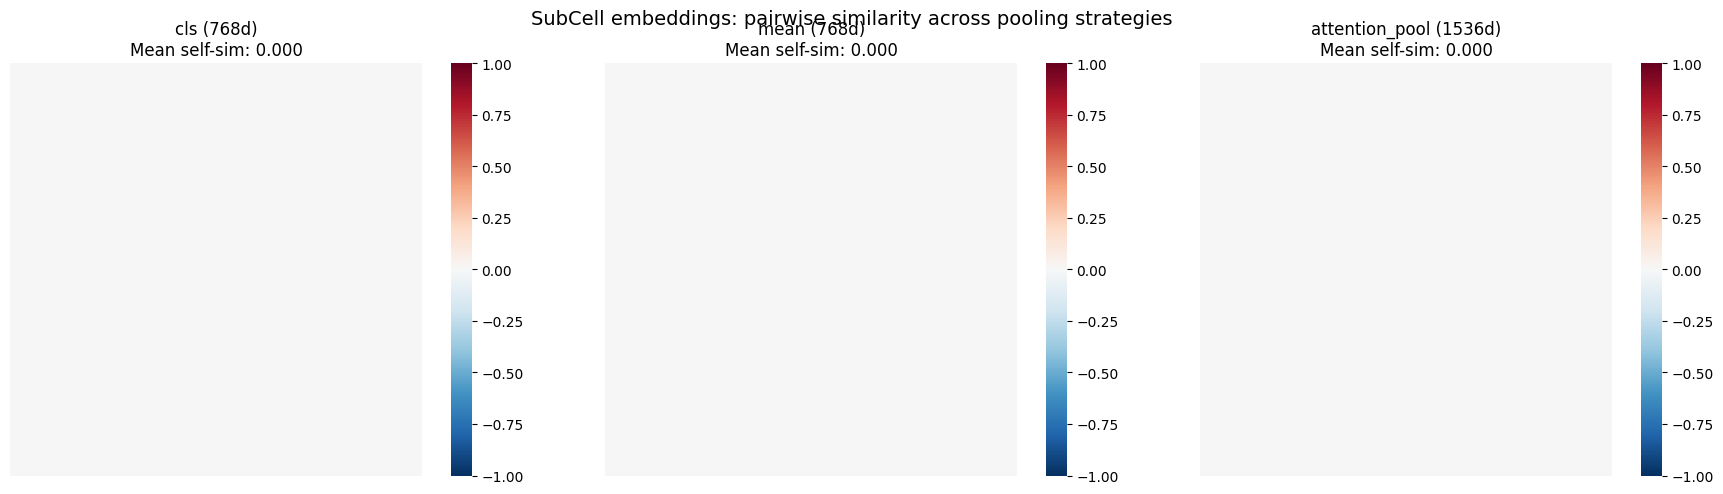

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (strategy, embs) in zip(axes, pooling_results.items()):
    sim = cosine_similarity(embs)
    sns.heatmap(sim, cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"{strategy} ({embs.shape[1]}d)\nMean self-sim: {sim[np.triu_indices_from(sim, k=1)].mean():.3f}")

fig.suptitle("SubCell embeddings: pairwise similarity across pooling strategies", fontsize=14)
plt.tight_layout()
plt.show()

### 11.2 Compare SubCell model variants

Load multiple SubCell architectures (MAE vs ViT) and channel
configurations to see how embeddings differ.

In [ ]:
model_variants = ["subcell_mae_rybg", "subcell_vit_rybg", "subcell_mae_rbg", "subcell_mae_bg"]
model_embeddings = {}

for variant in model_variants:
    print(f"Loading {variant}...")
    w = SubCellWrapper(model_path_or_name=variant)
    w.load(device)

    n_ch = SUBCELL_MODELS[variant]["num_channels"]
    images = [img[:n_ch] for img in synthetic_images]

    embs = w.embed_batch(images, pooling_strategy="cls")
    model_embeddings[variant] = np.array(embs)
    print(f"  {variant}: {model_embeddings[variant].shape}")

    del w
    torch.cuda.empty_cache()

print(f"\nEmbedded {N_SYNTHETIC} images with {len(model_variants)} SubCell variants")

INFO:embpy.models.morphology_models:Loading SubCell encoder: subcell_mae_rybg (4ch)...


Loading subcell_mae_rybg...


INFO:embpy.models.morphology_models:SubCell loaded. Embedding dim: 1536 (attention_pool)
INFO:embpy.models.morphology_models:Downloading SubCell weight: all_channels_ViT-ProtS-Pool.pth


  subcell_mae_rybg: (20, 768)
Loading subcell_vit_rybg...


INFO:embpy.models.morphology_models:Downloaded 349.0 MB -> /home/icb/goncalo.pinto/.cache/embpy/subcell/all_channels_ViT-ProtS-Pool.pth
INFO:embpy.models.morphology_models:Loading SubCell encoder: subcell_vit_rybg (4ch)...
INFO:embpy.models.morphology_models:SubCell loaded. Embedding dim: 1536 (attention_pool)
INFO:embpy.models.morphology_models:Downloading SubCell weight: MT-DNA-Protein_MAE-CellS-ProtS-Pool.pth


  subcell_vit_rybg: (20, 768)
Loading subcell_mae_rbg...


In [ ]:
n_models = len(model_variants)
cross_model_corr = np.zeros((n_models, n_models))

for i, m1 in enumerate(model_variants):
    for j, m2 in enumerate(model_variants):
        e1 = model_embeddings[m1]
        e2 = model_embeddings[m2]
        per_sample_corr = [np.corrcoef(e1[k], e2[k])[0, 1] for k in range(N_SYNTHETIC)]
        cross_model_corr[i, j] = np.nanmean(per_sample_corr)

short_names = [v.replace("subcell_", "") for v in model_variants]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cross_model_corr, annot=True, fmt=".3f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True,
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title("Cross-model Pearson correlation (per-sample, averaged)")
plt.tight_layout()
plt.show()

### 11.3 Embedding landscape (PCA projection)

Project SubCell embeddings to 2D to visualise how different models
arrange the same set of images.

In [ ]:
from sklearn.decomposition import PCA as PCADecomp

fig, axes = plt.subplots(1, len(model_variants), figsize=(5 * len(model_variants), 4.5))

for ax, variant in zip(axes, model_variants):
    embs = model_embeddings[variant]
    pca2d = PCADecomp(n_components=2).fit_transform(embs)
    scatter = ax.scatter(pca2d[:, 0], pca2d[:, 1], c=np.arange(N_SYNTHETIC),
                         cmap="viridis", s=60, edgecolors="black", linewidths=0.5)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(variant.replace("subcell_", ""))
    for k in range(N_SYNTHETIC):
        ax.annotate(str(k), (pca2d[k, 0], pca2d[k, 1]), fontsize=7, ha="center", va="bottom")

fig.suptitle("SubCell embedding landscape (PCA of CLS embeddings)", fontsize=14)
plt.tight_layout()
plt.show()

### 11.4 Store SubCell embeddings as AnnData

Combine all SubCell model embeddings into a single AnnData object
for downstream integration with other `embpy` modalities.

In [ ]:
import anndata as ad

primary_embs = pooling_results["attention_pool"]

adata_subcell = ad.AnnData(
    X=primary_embs,
    obs=pd.DataFrame({
        "image_id": [f"synthetic_{i:03d}" for i in range(N_SYNTHETIC)],
    }),
)

for strategy, embs in pooling_results.items():
    adata_subcell.obsm[f"X_subcell_{strategy}"] = embs

for variant, embs in model_embeddings.items():
    short = variant.replace("subcell_", "")
    adata_subcell.obsm[f"X_{short}_cls"] = embs

print(adata_subcell)
print(f"\nStored embedding keys: {list(adata_subcell.obsm.keys())}")

### 11.5 Embedding norms and distributions

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

norms_by_model = {v.replace("subcell_", ""): np.linalg.norm(e, axis=1)
                  for v, e in model_embeddings.items()}
norm_df = pd.DataFrame(norms_by_model)
norm_df.plot.box(ax=axes[0])
axes[0].set_ylabel("L2 norm")
axes[0].set_title("Embedding magnitude by model variant")

norms_by_pool = {s: np.linalg.norm(e, axis=1) for s, e in pooling_results.items()}
pool_df = pd.DataFrame(norms_by_pool)
pool_df.plot.box(ax=axes[1])
axes[1].set_ylabel("L2 norm")
axes[1].set_title("Embedding magnitude by pooling strategy")

plt.tight_layout()
plt.show()

### 11.6 Raw per-patch token embeddings (no pooling)

Pass `pooling_strategy="none"` to get the full sequence of per-patch
tokens -- useful for spatial analysis, attention maps, or downstream
models that consume per-patch features.

In [ ]:
test_img = synthetic_images[0]

raw_tokens = wrapper.embed(test_img, pooling_strategy="none")
print(f"Raw token output: {raw_tokens.shape}")
print(f"  Token 0 (CLS):     {raw_tokens[0, :5]}...")
print(f"  Tokens 1-784:      patch embeddings")

n_patches_side = 448 // 16
patch_norms = np.linalg.norm(raw_tokens[1:], axis=1)
spatial_norms = patch_norms.reshape(n_patches_side, n_patches_side)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(test_img[:3].transpose(1, 2, 0))
axes[0].set_title("Input image (RGB channels)")
axes[0].axis("off")

im = axes[1].imshow(spatial_norms, cmap="hot", interpolation="nearest")
axes[1].set_title(f"Patch embedding norms ({n_patches_side}x{n_patches_side})")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], shrink=0.8)

axes[2].hist(patch_norms, bins=30, edgecolor="white", color="coral")
axes[2].set_xlabel("L2 norm")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of patch norms")

plt.tight_layout()
plt.show()

### 11.7 Using SubCell with real JUMP images

To apply SubCell to actual JUMP Cell Painting images, download
single-cell crops from the [Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/)
and remap channels with `jump_to_subcell()`:

```python
jump_image = np.load("jump_cell_crop.npy")  # (5, H, W): DNA, ER, RNA, AGP, Mito
subcell_input = jump_to_subcell(jump_image)  # (4, H, W): RYBG

emb = wrapper.embed(subcell_input, pooling_strategy="attention_pool")  # (1536,)
tokens = wrapper.embed(subcell_input, pooling_strategy="none")         # (785, 768)
```

## Summary

This tutorial showed how to:

- **Load** JUMP Cell Painting CRISPR embeddings (259-dim, Harmony + PCA corrected)
- **Map** JCP2022 IDs to gene symbols with `broad-babel`
- **Separate** treatments from negative controls
- **Aggregate** per-gene mean embeddings across replicate wells
- **Find** morphologically similar gene perturbations via cosine similarity
- **Visualise** the morphological landscape with PCA and heatmaps
- **Store** embeddings as AnnData for integration with `embpy`
- **Generate** SubCell morphology embeddings from fluorescence images
- **Compare** 8 SubCell model variants and 4 pooling strategies (cls, mean, attention_pool, none)
- **Inspect** raw per-patch token embeddings for spatial analysis

### Data sources

- **JUMP CRISPR embeddings**: [Cell Painting Gallery](https://registry.opendata.aws/cellpainting-gallery/) (cpg0016, CRISPR v1.0a)
- **SubCell weights**: [CZI SubCell](https://github.com/CellProfiling/SubCellPortable), auto-downloaded from S3

### References

- Chandrasekaran et al., *Nature Methods* (2025). JUMP Morphmap
- Cimini et al., *Nature Protocols* (2023). Cell Painting protocol
- Leek et al., *SubCell: Vision foundation models for microscopy* (2024)